In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE


df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

print("\nClass Distribution:")
print(df['Class'].value_counts())

X = df.drop('Class', axis=1)
y = df['Class']


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled,
    test_size=0.3,
    random_state=42
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

def evaluate_model(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

lr_results = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

rf_results = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": lr_results,
    "Random Forest": rf_results
})

print("\nMODEL COMPARISON")
print(comparison_df)

print("\nONCLUSION")
print("Random Forest is generally better for fraud detection because it achieves higher Recall and F1-score, which are critical for imbalanced datasets.")

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

Dataset Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePri

/tmp/ipykernel_9272/3748734385.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_9272/3748734385.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

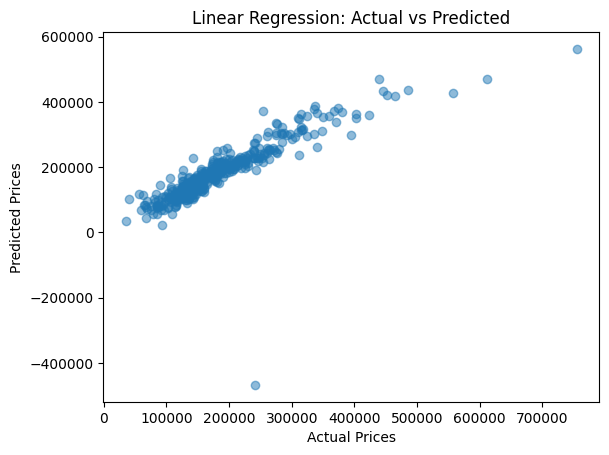


FINAL CONCLUSION
Decision Tree performed better (lower RMSE).

Note:
Lower MAE and RMSE indicate better model performance.


In [3]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/train (1).csv")

print("Dataset Shape:", df.shape)
print(df.head())

missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nMissing Values:\n", missing.sort_values(ascending=False).head(10))

for col in df.columns:
    if df[col].dtype == "object":
        # categorical
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        # numerical
        df[col].fillna(df[col].median(), inplace=True)


df = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding Shape:", df.shape)

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n===== {name} =====")
    print("MAE  :", mae)
    print("RMSE :", rmse)

    return mae, rmse

lr_mae, lr_rmse = evaluate_model("Linear Regression", y_test, y_pred_lr)
dt_mae, dt_rmse = evaluate_model("Decision Tree", y_test, y_pred_dt)

# Creating a small comparison table
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "LR Predicted": y_pred_lr,
    "DT Predicted": y_pred_dt
})

print("\nSample Predictions:\n")
print(comparison.head(10))


plt.figure()

# Scatter plot for Linear Regression
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()


print("\nFINAL CONCLUSION")

if dt_rmse < lr_rmse:
    print("Decision Tree performed better (lower RMSE).")
else:
    print("Linear Regression performed better (lower RMSE).")

print("\nNote:")
print("Lower MAE and RMSE indicate better model performance.")

Dataset Shape: (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  C

/tmp/ipykernel_9272/4149204585.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


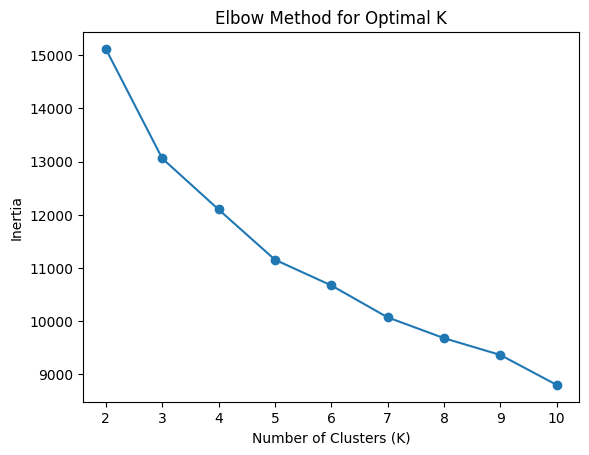

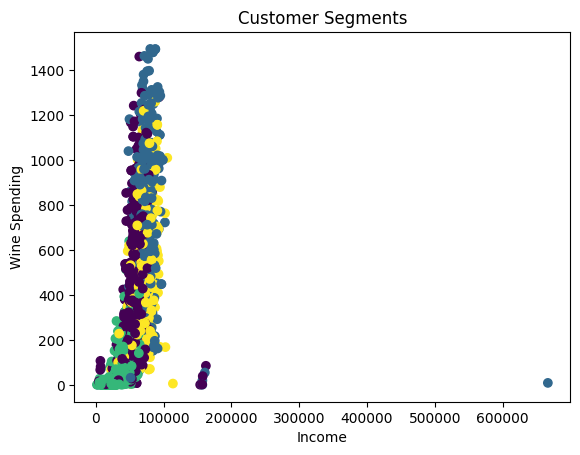


Cluster Distribution:
Cluster
2    948
0    626
1    354
3    312
Name: count, dtype: int64

Sample Data with Cluster Labels:
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  Cluster  
0              172                88            88        3  
1                2                 1             6        2  
2              111                21            42        1  
3               10                 3             5        2  
4               46                27            15        2  


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt


df = pd.read_csv("/content/drive/MyDrive/marketing_campaign.csv", sep='\t')

print("Dataset Shape:", df.shape)
print(df.head())


features = [
    "Income", "Kidhome", "Teenhome",
    "Recency", "MntWines", "MntFruits",
    "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds"
]

df = df[features]

print("\nSelected Features:\n", df.columns)


for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


plt.figure()
plt.scatter(df["Income"], df["MntWines"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Wine Spending")
plt.title("Customer Segments")
plt.show()


print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

print("\nSample Data with Cluster Labels:")
print(df.head())